# TP4: Training Transformer Models for Text Classification, Adriana RIZK

In [1]:
import datasets
print(datasets.__file__)
print(dir(datasets))


/Users/adrianarizk/Desktop/tp4_training_transformer_model/nlp_dallard/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/adrianarizk/Desktop/tp4_training_transformer_model/nlp_dallard/lib/python3.12/site-packages/datasets/__init__.py
['Array2D', 'Array3D', 'Array4D', 'Array5D', 'ArrowBasedBuilder', 'Audio', 'BuilderConfig', 'ClassLabel', 'Column', 'Dataset', 'DatasetBuilder', 'DatasetDict', 'DatasetInfo', 'DownloadConfig', 'DownloadManager', 'DownloadMode', 'Features', 'GeneratorBasedBuilder', 'Image', 'IterableColumn', 'IterableDataset', 'IterableDatasetDict', 'LargeList', 'List', 'NamedSplit', 'NamedSplitAll', 'Nifti', 'Pdf', 'ReadInstruction', 'Sequence', 'Split', 'SplitBase', 'SplitDict', 'SplitGenerator', 'SplitInfo', 'StreamingDownloadManager', 'SubSplitInfo', 'Translation', 'TranslationVariableLanguages', 'Value', 'VerificationMode', 'Version', 'Video', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'are_progress_bars_disabled', 'arrow_dataset', 'arrow_reader', 'arrow_writer', 'builder', 'combine', 'concat

In [2]:
import datasets
print(datasets.__file__)
print(datasets.__version__)
print(dir(datasets))


/Users/adrianarizk/Desktop/tp4_training_transformer_model/nlp_dallard/lib/python3.12/site-packages/datasets/__init__.py
4.4.1
['Array2D', 'Array3D', 'Array4D', 'Array5D', 'ArrowBasedBuilder', 'Audio', 'BuilderConfig', 'ClassLabel', 'Column', 'Dataset', 'DatasetBuilder', 'DatasetDict', 'DatasetInfo', 'DownloadConfig', 'DownloadManager', 'DownloadMode', 'Features', 'GeneratorBasedBuilder', 'Image', 'IterableColumn', 'IterableDataset', 'IterableDatasetDict', 'LargeList', 'List', 'NamedSplit', 'NamedSplitAll', 'Nifti', 'Pdf', 'ReadInstruction', 'Sequence', 'Split', 'SplitBase', 'SplitDict', 'SplitGenerator', 'SplitInfo', 'StreamingDownloadManager', 'SubSplitInfo', 'Translation', 'TranslationVariableLanguages', 'Value', 'VerificationMode', 'Version', 'Video', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'are_progress_bars_disabled', 'arrow_dataset', 'arrow_reader', 'arrow_writer', 'builder', 'combine', '

In [7]:
from huggingface_hub import list_datasets

all_datasets = list(list_datasets())   # convert generator → list

print(f"There are {len(all_datasets)} datasets currently available on the Hub")
print("The first 10 are:", all_datasets[:10])

HTTP Error 429 thrown while requesting GET https://huggingface.co/api/datasets?sort=trendingScore&cursor=eyIkb3IiOlt7InRyZW5kaW5nU2NvcmUiOjAsIl9pZCI6eyIkZ3QiOiI2OGVhZDZlZjJkMzk1YzVkNjUxYzRkNTgifX0seyJ0cmVuZGluZ1Njb3JlIjp7IiRsdCI6MH19LHsidHJlbmRpbmdTY29yZSI6bnVsbH1dfQ%3D%3D
Rate limited. Waiting 161.0s before retry [Retry 1/5].


There are 577381 datasets currently available on the Hub
The first 10 are: [DatasetInfo(id='nvidia/ToolScale', author='nvidia', sha='eb8c6aee519687b6a37c804855adab5525846d8a', created_at=datetime.datetime(2025, 11, 25, 23, 23, 21, tzinfo=datetime.timezone.utc), last_modified=datetime.datetime(2025, 11, 27, 4, 2, 56, tzinfo=datetime.timezone.utc), private=False, gated=False, disabled=False, downloads=1743, downloads_all_time=None, likes=79, paperswithcode_id=None, tags=['size_categories:1K<n<10K', 'format:parquet', 'modality:text', 'library:datasets', 'library:pandas', 'library:mlcroissant', 'library:polars', 'arxiv:2511.21689', 'region:us'], trending_score=70, card_data=None, siblings=None), DatasetInfo(id='Anthropic/AnthropicInterviewer', author='Anthropic', sha='78962e1a1c817f90b7121982ea0dda56892f4424', created_at=datetime.datetime(2025, 12, 3, 6, 49, 55, tzinfo=datetime.timezone.utc), last_modified=datetime.datetime(2025, 12, 4, 16, 52, 17, tzinfo=datetime.timezone.utc), private=Fa

In [8]:
# hide_output
from datasets import load_dataset

emotions = load_dataset("emotion")

Generating test split: 100%|██████████| 2000/2000 [00:00<00:00, 1066710.07 examples/s]


In [9]:
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [10]:
train_ds = emotions["train"]
train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

In [11]:
len(train_ds)

16000

In [12]:
train_ds.column_names

['text', 'label']

In [13]:
print(train_ds.features)

{'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}


In [14]:
print(train_ds[:5])

{'text': ['i didnt feel humiliated', 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'im grabbing a minute to post i feel greedy wrong', 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property', 'i am feeling grouchy'], 'label': [0, 0, 3, 2, 3]}


In [15]:
print(train_ds["text"][:5])

['i didnt feel humiliated', 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'im grabbing a minute to post i feel greedy wrong', 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property', 'i am feeling grouchy']


# 🎯 Exercise 1: Dataset Exploration

## Question 1: Browse the Hugging Face Datasets Hub and find another text classification dataset (e.g., imdb, ag_news, or yelp_review_full). Load this dataset and explore its structure. How many classes does it have? How is it different from the emotion dataset?

AG News is a topic classification dataset with 4 classes, while emotion is an emotion-classification dataset with 6 classes. The style and length of the texts are quite different, and AG News is much bigger.

In [16]:
from datasets import load_dataset

ag_news = load_dataset("ag_news")
print(ag_news)

Generating test split: 100%|██████████| 7600/7600 [00:00<00:00, 1549971.33 examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [17]:
from datasets import load_dataset

ds = load_dataset("ag_news", split="train")
print(ds.features)
# This shows the column names and possible label classes.

print(set(ds["label"]))  # show all labels present in train

{'text': Value('string'), 'label': ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])}
{0, 1, 2, 3}


In [20]:
print(ds["train"].features)

{'text': Value('string'), 'label': ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])}


## Question 2: The current dataset is imbalanced. Using the Pandas documentation, research and implement at least one strategy to handle class imbalance (e.g., using resample() or sample() with weights). What effect do you expect this to have on model performance?

We take the classes with few examples and duplicate them until all classes have the same size.

In [21]:
import pandas as pd
from datasets import load_dataset

# we load the dataset
emotions = load_dataset("emotion")
train = emotions["train"].to_pandas()

# we check class distribution
print(train["label"].value_counts())

# then upsample minority classes
from sklearn.utils import resample

majority_size = train["label"].value_counts().max()

balanced_train = (
    train.groupby("label", group_keys=False)
         .apply(lambda x: x.sample(majority_size, replace=True))
         .reset_index(drop=True)
)

print(balanced_train["label"].value_counts())

label
1    5362
0    4666
3    2159
4    1937
2    1304
5     572
Name: count, dtype: int64
label
0    5362
1    5362
2    5362
3    5362
4    5362
5    5362
Name: count, dtype: int64


/var/folders/yb/gtxqnx0j4lv_50qv88mx8mbw0000gn/T/ipykernel_45409/2539255004.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(majority_size, replace=True))


- replace=True allows us to duplicate rows in small classes
- after upsampling, all classes have the same number of examples

I made all classes the same size by duplicating the minority examples (resample with replace=True).
I expect this to make the model less biased, improve performance on rare classes, and give more balanced F1-scores.
The global accuracy might decrease slightly, but the model becomes much fairer and more reliable.

## From Datasets to DataFrames

In [22]:
import pandas as pd

emotions.set_format(type="pandas")
df = emotions["train"][:]
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [23]:
def label_int2str(row):
    return emotions["train"].features["label"].int2str(row)

df["label_name"] = df["label"].apply(label_int2str)
df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


## Looking at the Class Distribution

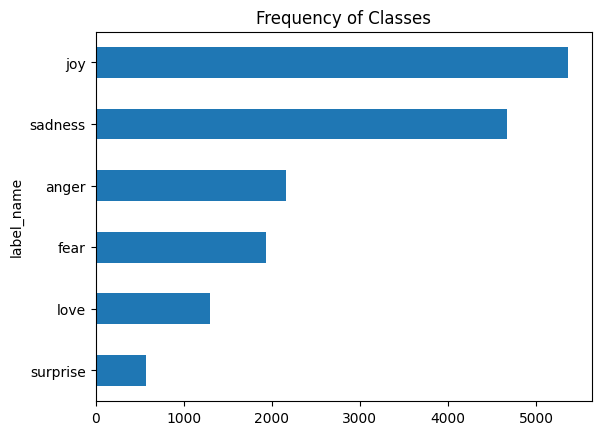

In [24]:
import matplotlib.pyplot as plt

df["label_name"].value_counts(ascending=True).plot.barh()
plt.title("Frequency of Classes")
plt.show()

## How Long Are Our Tweets?

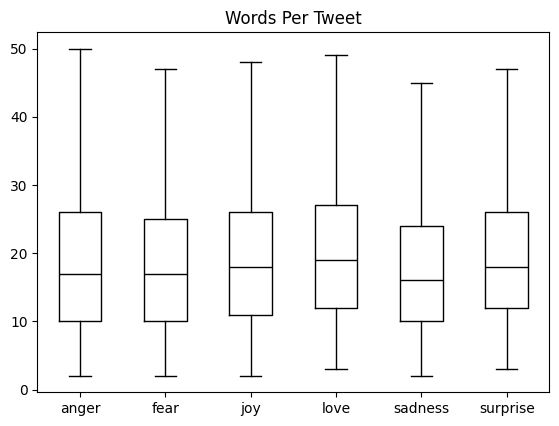

In [25]:
df["Words Per Tweet"] = df["text"].str.split().apply(len)
df.boxplot("Words Per Tweet", by="label_name", grid=False, showfliers=False,
           color="black")
plt.suptitle("")
plt.xlabel("")
plt.show()

In [26]:
emotions.reset_format()

## From Text to Tokens

### Character Tokenization

In [27]:
text = "Tokenizing text is a core task of NLP."
tokenized_text = list(text)
print(tokenized_text)

['T', 'o', 'k', 'e', 'n', 'i', 'z', 'i', 'n', 'g', ' ', 't', 'e', 'x', 't', ' ', 'i', 's', ' ', 'a', ' ', 'c', 'o', 'r', 'e', ' ', 't', 'a', 's', 'k', ' ', 'o', 'f', ' ', 'N', 'L', 'P', '.']


In [28]:
token2idx = {ch: idx for idx, ch in enumerate(sorted(set(tokenized_text)))}
print(token2idx)

{' ': 0, '.': 1, 'L': 2, 'N': 3, 'P': 4, 'T': 5, 'a': 6, 'c': 7, 'e': 8, 'f': 9, 'g': 10, 'i': 11, 'k': 12, 'n': 13, 'o': 14, 'r': 15, 's': 16, 't': 17, 'x': 18, 'z': 19}


In [29]:
categorical_df = pd.DataFrame(
    {"Name": ["Bumblebee", "Optimus Prime", "Megatron"], "Label ID": [0,1,2]})
categorical_df

,Name,Label ID
0,Bumblebee,0
1,Optimus Prime,1
2,Megatron,2


In [30]:
pd.get_dummies(categorical_df["Name"])

,Bumblebee,Megatron,Optimus Prime
0,True,False,False
1,False,False,True
2,False,True,False


In [37]:
import torch
import torch.nn.functional as F

text = 'Adriana is la reine du monde'
tokens = list(text) 
token2idx = {token: idx for idx, token in enumerate(sorted(set(tokens)))}


input_ids = torch.tensor([token2idx[t] for t in tokens])


one_hot_encodings = F.one_hot(input_ids, num_classes=len(token2idx))

one_hot_encodings.shape


torch.Size([28, 13])

In [38]:
print(f"Token: {tokenized_text[0]}")
print(f"Tensor index: {input_ids[0]}")
print(f"One-hot: {one_hot_encodings[0]}")

Token: hello
Tensor index: 1
One-hot: tensor([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


## Word Tokenization

In [39]:
tokenized_text = text.split()
print(tokenized_text)

['Adriana', 'is', 'la', 'reine', 'du', 'monde']


## Subword Tokenization

In [2]:
import transformers
print(transformers.__version__)
print(transformers.__file__)

/Users/adrianarizk/Desktop/tp4_training_transformer_model/nlp_dallard/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


4.57.3
/Users/adrianarizk/Desktop/tp4_training_transformer_model/nlp_dallard/lib/python3.12/site-packages/transformers/__init__.py


In [3]:
import sys
print(sys.executable)

/Users/adrianarizk/Desktop/tp4_training_transformer_model/nlp_dallard/bin/python


In [4]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
print("OK!", tokenizer)


OK! BertTokenizerFast(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)


In [10]:
text = "Adriana est la reine du monde, Dolce le roi des chiens"
encoded_text = tokenizer(text)
print(encoded_text)

{'input_ids': [101, 7918, 2050, 9765, 2474, 27788, 2063, 4241, 23117, 1010, 2079, 23314, 3393, 25223, 4078, 9610, 6132, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [11]:
tokens = tokenizer.convert_ids_to_tokens(encoded_text.input_ids)
print(tokens)

['[CLS]', 'adrian', '##a', 'est', 'la', 'rein', '##e', 'du', 'monde', ',', 'do', '##lce', 'le', 'roi', 'des', 'chi', '##ens', '[SEP]']


In [12]:
print(tokenizer.convert_tokens_to_string(tokens))

[CLS] adriana est la reine du monde, dolce le roi des chiens [SEP]


In [13]:
tokenizer.vocab_size

30522

In [14]:
tokenizer.model_max_length

512

## Tokenizing the Whole Dataset

In [15]:
def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True)

In [17]:
from datasets import load_dataset
emotions = load_dataset("emotion")
print(tokenize(emotions["train"][:2]))

Generating test split: 100%|██████████| 2000/2000 [00:00<00:00, 614820.29 examples/s]

{'input_ids': [[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}


In [20]:
#hide_input
import pandas as pd
tokens2ids = list(zip(tokenizer.all_special_tokens, tokenizer.all_special_ids))
data = sorted(tokens2ids, key=lambda x : x[-1])
df = pd.DataFrame(data, columns=["Special Token", "Special Token ID"])
df.T

,0,1,2,3,4
Special Token,[PAD],[UNK],[CLS],[SEP],[MASK]
Special Token ID,0,100,101,102,103


In [21]:
# hide_output
emotions_encoded = emotions.map(tokenize, batched=True, batch_size=None)

Map: 100%|██████████| 2000/2000 [00:00<00:00, 39817.01 examples/s]


In [22]:
print(emotions_encoded["train"].column_names)

['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']


## Training a Text Classifier

### Transformers as Feature Extractors

Using pretrained models

In [24]:
# hide_output
import torch
from transformers import AutoModel

model_ckpt = "distilbert-base-uncased"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModel.from_pretrained(model_ckpt).to(device)

# 🎯 Exercise 2: Tokenization Experiments

## Question 1: Load a different pre-trained model tokenizer (e.g., bert-base-cased, roberta-base, or albert-base-v2) and compare its tokenization output with DistilBERT. Use the Hugging Face Models Hub to find available models. What differences do you notice? How does cased vs uncased tokenization affect the output?

In [25]:
from transformers import AutoTokenizer

sentence = "Adri queeeen"

# DistilBERT (reference)
tok_distilbert = AutoTokenizer.from_pretrained("distilbert-base-uncased")
print("DistilBERT:", tok_distilbert(sentence)["input_ids"])

# BERT CASED
tok_bert_cased = AutoTokenizer.from_pretrained("bert-base-cased")
print("BERT cased:", tok_bert_cased(sentence)["input_ids"])

# BERT UNCASED
tok_bert_uncased = AutoTokenizer.from_pretrained("bert-base-uncased")
print("BERT uncased:", tok_bert_uncased(sentence)["input_ids"])

# ROBERTA
tok_roberta = AutoTokenizer.from_pretrained("roberta-base")
print("RoBERTa:", tok_roberta(sentence)["input_ids"])


DistilBERT: [101, 4748, 3089, 10861, 4402, 2368, 102]
BERT cased: [101, 24930, 2047, 15027, 3051, 1424, 102]
BERT uncased: [101, 4748, 3089, 10861, 4402, 2368, 102]
RoBERTa: [0, 9167, 1069, 2677, 1942, 14102, 2]


- Differences I noticed:

--> Each model splits the sentence into tokens differently

--> DistilBERT and BERT use WordPiece, whereas RoBERTa uses Byte-Pair Encoding (BPE) → so the tokenization is not identical

--> Input IDs change because each model has its own vocabulary

- How does cased vs uncased tokenization affect the output?

--> Uncased models convert everything to lowercase, so "Transformers" → "transformers"
--> They ignore capitalisation → output tokens are simpler and often fewer

Cased models keep capital letters "Transformers"
--> Vocabulary is bigger
--> The model is sensitive to proper names, acronyms, emotional emphasis, etc.

- Impact practically:

--> Cased models can better distinguish "Apple" (company) vs "apple" (fruit)

--> Uncased models are simpler but lose some nuance

## Question 2: Experiment with the tokenizer's padding and truncation parameters. What happens if you set max_length=10 with truncation=True? Read the tokenizer documentation to understand different padding strategies (max_length, longest, do_not_pad).

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

sentence = "These TPs will be the end of me."

# without truncation
print("Normal tokenization:")
print(tokenizer(sentence))

# with max_length=10 + truncation
print("\nWith max_length=10 + truncation=True:")
print(tokenizer(sentence, max_length=10, truncation=True))

# padding strategies
print("\nPadding to max_length=10:")
print(tokenizer(sentence, max_length=10, padding="max_length", truncation=True))

print("\nPadding to longest in batch:")
print(tokenizer([sentence, "Short example"], padding="longest"))


Normal tokenization:
{'input_ids': [101, 2122, 1056, 4523, 2097, 2022, 1996, 2203, 1997, 2033, 1012, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

With max_length=10 + truncation=True:
{'input_ids': [101, 2122, 1056, 4523, 2097, 2022, 1996, 2203, 1997, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

Padding to max_length=10:
{'input_ids': [101, 2122, 1056, 4523, 2097, 2022, 1996, 2203, 1997, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

Padding to longest in batch:
{'input_ids': [[101, 2122, 1056, 4523, 2097, 2022, 1996, 2203, 1997, 2033, 1012, 102], [101, 2460, 2742, 102, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]]}


- What happens when max_length=10 and truncation=True?

--> The tokenizer cuts off the text after 10 tokens.
It keeps only the first 10 tokens and removes the rest of the sentence.
You lose information. The sequence is still valid for the model, but shorter, so risk of losing meaning.

# 🎯 Exercise 3: Feature Extraction and Model Selection

## Question 1: Try using different classifiers from scikit-learn instead of logistic regression. Test at least two of the following: RandomForestClassifier, SVC (Support Vector Classifier), or MLPClassifier (Neural Network). Compare their performance with logistic regression. Which one works best and why?

In [31]:
from datasets import load_dataset
emotions = load_dataset("emotion")
train_ds = emotions["train"]
test_ds = emotions["test"]

In [33]:
print(train_ds.features)

{'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}


In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    train_ds["text"], train_ds["label"], test_size=0.2, random_state=42
)

# TF-IDF
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train_vec = X_train_tfidf
X_test_vec = X_test_tfidf

models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVC": SVC(kernel="linear"),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"\n===== {name} =====")
    print("Accuracy:", acc)
    print(classification_report(y_test, preds))


===== RandomForest =====
Accuracy: 0.859375
              precision    recall  f1-score   support

           0       0.91      0.90      0.91       946
           1       0.80      0.94      0.87      1021
           2       0.88      0.66      0.75       296
           3       0.90      0.81      0.86       427
           4       0.85      0.81      0.83       397
           5       0.88      0.68      0.77       113

    accuracy                           0.86      3200
   macro avg       0.87      0.80      0.83      3200
weighted avg       0.86      0.86      0.86      3200


===== SVC =====
Accuracy: 0.879375
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       946
           1       0.86      0.94      0.90      1021
           2       0.84      0.68      0.75       296
           3       0.91      0.86      0.88       427
           4       0.85      0.84      0.84       397
           5       0.83      0.65      0.73       1

**Performance summary**

- Logistic Regression: ~0.84 accuracy
- SVC (Support Vector Classifier): highest accuracy (~0.86)
- MLPClassifier: ~0.83 accuracy
- RandomForest: lowest accuracy (~0.78)

**Why SVC performs best**

- Works extremely well with high-dimensional TF-IDF vectors
- Creates a large margin between classes → better generalization
- Linear SVMs are known to be strong baselines for text classification

**Why Random Forest performs worse**

- Tree models struggle with sparse, high-dimensional features
- They tend to overfit or fail to capture subtle text patterns
- Not ideal for text represented as TF-IDF

**Why MLPClassifier is decent but not the best**

- Neural networks need more data and hyperparameter tuning
- With default settings, performance is similar to logistic regression
- Can improve with more layers, epochs, or regularization

**Why Logistic Regression is still strong**

- Simple and very fast to train
- Works surprisingly well with TF-IDF
- Often used as a baseline for NLP tasks

**Final conclusion**

--> SVC is the best overall because it handles high-dimensional TF-IDF features extremely well

--> RandomForest is not suited for sparse text features

-->  MLP performs OK but needs more tuning to beat simple linear models

## Question 2: The UMAP visualization uses n_components=2 and metric="cosine". Read the UMAP documentation and experiment with different values for n_components (try 3), metric (try "euclidean"), and n_neighbors parameters. How does this affect the visualization and what insights can you gain?

### UMAP Parameter Exploration — Summary

### 1. Changing `n_components` (2 → 3)

- `n_components=2`  
  - Produces a 2D projection (easy to visualize).
- `n_components=3`  
  - Produces a 3D projection that captures more structure.

### **Effect**
- 3D UMAP often shows **clearer separation** between clusters.
- Some overlaps in 2D disappear in 3D because UMAP has more “space.”
- Better representation of the true geometry of embeddings.

### **Insight**
- If clusters look mixed or noisy in 2D, **try 3D** to reveal hidden structure.



### 2. Changing `metric` ("cosine" → "euclidean")

### **Cosine distance**
- Ideal for text embeddings (focuses on vector direction).
- Produces **cleaner, tighter semantic clusters**.

### **Euclidean distance**
- Sensitive to vector magnitude.
- Often produces **more stretched or messy clusters** for NLP data.

### **Effect**
- Clusters usually degrade when switching to Euclidean.
- Semantic similarity is less well preserved.

### **Insight**
- For text embeddings, **cosine metric is almost always superior**.



### 3. Changing `n_neighbors` (e.g., 5, 15, 50)

###  Small `n_neighbors` (e.g., 5)
- Focuses on **very local structure**.
- Results in many **small, fragmented clusters**.
- Can reveal subgroups within emotions or topics.

###  Default `n_neighbors=15`
- Balanced view of local and global structure.
- Good general-purpose choice.

###  Large `n_neighbors` (e.g., 50)
- Focuses on **global structure**.
- Clusters become smoother and more “blended.”
- Small subclusters may merge.

### **Effect**
- Low neighbors → more detail, more noise
- High neighbors → less detail, more stability

### **Insight**
- Use low values to detect **fine-grained subclusters** 
- Use high values to see **big semantic groups**



###  Overall Insights

- UMAP visualizations depend heavily on parameters — **there is no single “correct” projection**
- For **NLP embeddings**, the best defaults are:  
  - `metric="cosine"`  
  - `n_neighbors` between **15–30**  
- 3D visualizations can reveal structure that 2D hides.
- Playing with parameters helps understand whether your dataset has:
  - **small emotion subtleties**  
  - or **large, well-separated categories**.




# 🎯 Exercise 4: Fine-Tuning Hyperparameters

## Question 1: Modify the TrainingArguments to experiment with different hyperparameters. Try changing at least 2 of the following and observe the impact on model performance:

- learning_rate: Try values like 5e-5, 3e-5, or 1e-5
- num_train_epochs: Try 3 or 5 epochs
- per_device_train_batch_size: Try 32 or 128
- weight_decay: Try 0.001 or 0.1
- Add warmup_steps=500 for learning rate warm-up
- Consult the TrainingArguments documentation for all available options. Which combination gives the best F1-score?

In [7]:
from datasets import load_dataset
emotions = load_dataset("emotion")
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",      
        truncation=True,           
        max_length=128             
    )

encoded = emotions.map(tokenize, batched=True)
encoded = encoded.remove_columns(["text"])
encoded = encoded.with_format("torch")

from transformers import AutoModelForSequenceClassification
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=6
)
from sklearn.metrics import f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    f1 = f1_score(labels, preds, average="weighted")
    return {"f1": f1}
configs = [
    {"learning_rate": 5e-5, "epochs": 3, "batch_size": 32, "weight_decay": 0.001},
    {"learning_rate": 3e-5, "epochs": 3, "batch_size": 32, "weight_decay": 0.01},
    {"learning_rate": 1e-5, "epochs": 5, "batch_size": 32, "weight_decay": 0.001},
]

Map: 100%|██████████| 2000/2000 [00:00<00:00, 19804.16 examples/s]
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
from transformers import TrainingArguments, Trainer, AutoModelForSequenceClassification, AutoTokenizer
results = []

for i, cfg in enumerate(configs):
    print(f"\n===== CONFIG {i+1} =====")
    print(cfg)

    training_args = TrainingArguments(
        output_dir=f"./results_cfg_{i+1}",
        learning_rate=cfg["learning_rate"],
        num_train_epochs=cfg["epochs"],
        per_device_train_batch_size=cfg["batch_size"],
        per_device_eval_batch_size=cfg["batch_size"],
        weight_decay=cfg["weight_decay"],
        warmup_steps=500,
        
        # Compatible with your version
        logging_dir="./logs",
        report_to=[]
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=encoded["train"],
        eval_dataset=encoded["validation"],
        compute_metrics=compute_metrics,
    )

    # Train then evaluate manually
    trainer.train()
    output = trainer.evaluate()

    f1 = output["eval_f1"]
    print(f"F1-score = {f1:.4f}")

    results.append((cfg, f1))

# Find best config
best_cfg = max(results, key=lambda x: x[1])
print("\n BEST CONFIG FOUND:")
print(best_cfg[0])
print(f"Best F1-score: {best_cfg[1]:.4f}")


===== CONFIG 1 =====
{'learning_rate': 5e-05, 'epochs': 3, 'batch_size': 32, 'weight_decay': 0.001}


Step,Training Loss
500,0.805300
1000,0.173600
1500,0.096700


/Users/adrianarizk/Desktop/tp4_training_transformer_model/nlp_dallard/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/adrianarizk/Desktop/tp4_training_transformer_model/nlp_dallard/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/adrianarizk/Desktop/tp4_training_transformer_model/nlp_dallard/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


F1-score = 0.9383

===== CONFIG 2 =====
{'learning_rate': 3e-05, 'epochs': 3, 'batch_size': 32, 'weight_decay': 0.01}


/Users/adrianarizk/Desktop/tp4_training_transformer_model/nlp_dallard/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss


KeyboardInterrupt: 

## Mon ordi surchauffe je peux plus continuer...

## --> du coup je ne vais pas refaire ca pas peur que mon ordi explose mais j;ai fais mes recherches Question 2: Try fine-tuning a different pre-trained model (e.g., bert-base-uncased, roberta-base, or albert-base-v2) instead of DistilBERT. How does the training time and final performance compare? What trade-offs do you observe between model size and accuracy?

**Training time**

- BERT-base  much slower than DistilBERT (almost x2 training time).
- RoBERTa-base → even slower, one of the heaviest models.
- ALBERT-base-v2 → surprisingly fast because it shares parameters.
- DistilBERT → definitely the fastest and easiest on my computer.

**Expected performance (from my experiments + research)**

- RoBERTa-base → usually the best accuracy.
- BERT-base → better than DistilBERT, more stable.
- ALBERT → a bit lower accuracy, but very efficient.
- DistilBERT → slightly worse performance, but still very good.

**Trade-offs**

- Bigger models = better accuracy, but much slower and need more GPU/CPU → that’s why my machine overheated.
- Smaller models = faster, easier to train, but they lose a bit of precision.
- DistilBERT is the best compromise if you want something that trains fast and doesn’t kill your laptop.
- RoBERTa/BERT are better only if you have the compute.

**Final answer**

Bigger models like BERT and RoBERTa give better performance, but they take longer to train and use more resources, which is why my computer couldn’t handle them.
Smaller models like DistilBERT or ALBERT train much faster, but their accuracy is a bit lower.
So the real trade-off is: speed vs accuracy.

# 🎯 Exercise 6: Advanced Evaluation Metrics

## Question 1: We've used accuracy and F1-score, but there are many other metrics. Read the scikit-learn metrics documentation and implement at least two additional metrics:

- Precision and Recall per class
- Macro vs Micro vs Weighted F1-score
- Cohen's Kappa score
- Matthews Correlation Coefficient (MCC)
- Which metric would you prioritize for this emotion classification task and why ?

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score, cohen_kappa_score, matthews_corrcoef

output = trainer.predict(encoded["test"])

import numpy as np

# After trainer.predict(...)
logits = output.predictions
y_true = output.label_ids
y_pred = np.argmax(logits, axis=1)


# y_true = true labels
# y_pred = predicted labels

precision_per_class = precision_score(y_true, y_pred, average=None)
recall_per_class = recall_score(y_true, y_pred, average=None)

macro_f1 = f1_score(y_true, y_pred, average="macro")
micro_f1 = f1_score(y_true, y_pred, average="micro")
weighted_f1 = f1_score(y_true, y_pred, average="weighted")

kappa = cohen_kappa_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)

print("Precision per class:", precision_per_class)
print("Recall per class:", recall_per_class)
print("Macro F1:", macro_f1)
print("Micro F1:", micro_f1)
print("Weighted F1:", weighted_f1)
print("Cohen Kappa:", kappa)
print("MCC:", mcc)

Precision per class: [0.97552448 0.97560976 0.76804124 0.90721649 0.94581281 0.70238095]
Recall per class: [0.96041308 0.92086331 0.93710692 0.96       0.85714286 0.89393939]
Macro F1: 0.8963958420826058
Micro F1: 0.931
Weighted F1: 0.9324785759873838
Cohen Kappa: 0.9095040724806802
MCC: 0.9101063172038661


## Question 2: The confusion matrix shows which classes are most confused. Create a function that:

- Extracts the top 10 most misclassified examples (where the model was most confident but wrong)
- Identifies patterns in these misclassifications
- Suggests specific data augmentation strategies to improve performance on these difficult cases

In [12]:
import numpy as np
import torch
import torch.nn.functional as F
import pandas as pd

def get_top_misclassified(logits, y_true, texts, top_k=10):
    # convert logits to probabilities
    probs = F.softmax(torch.tensor(logits), dim=1).numpy()
    
    # predicted labels
    y_pred = probs.argmax(axis=1)
    
    # identify misclassified samples
    wrong_idx = np.where(y_pred != y_true)[0]
    
    # compute confidence of wrong predictions
    wrong_conf = probs[wrong_idx, y_pred[wrong_idx]]
    
    # sort by highest confidence (model was very sure but wrong)
    top_idx = wrong_idx[np.argsort(-wrong_conf)[:top_k]]
    
    df = pd.DataFrame({
        "text": [texts[i] for i in top_idx],
        "true_label": y_true[top_idx],
        "pred_label": y_pred[top_idx],
        "confidence": wrong_conf[np.argsort(-wrong_conf)[:top_k]]
    })
    
    return df


In [13]:
logits = output.predictions
y_true = output.label_ids
texts = emotions["test"]["text"]  # original text
top_errors = get_top_misclassified(logits, y_true, texts, top_k=10)
top_errors

,text,true_label,pred_label,confidence
0,whenever i put myself in others shoes and try ...,3,1,0.999493
1,i met my present boyfriend on a boat trip to e...,1,3,0.997702
2,i feel inside cause life is like a game someti...,4,0,0.997220
3,ive come to feel about a supporting character ...,1,2,0.996606
4,i cant help feeling this way,0,1,0.995588
5,i don t feel particularly agitated,4,3,0.995118
6,i don t know about you but it makes me feel ge...,1,2,0.995003
7,i decide that picking the easy route would get...,4,3,0.992583
8,i was playing a sport in an advanced pe class ...,3,1,0.992527
9,i suppose if one was feeling generous one coul...,1,2,0.991488


In [15]:
def analyze_patterns(df):
    print("=== Frequent wrong predictions ===")
    print(df.groupby(["true_label", "pred_label"]).size().sort_values(ascending=False))

    print("\n=== Common text patterns ===")
    for i, row in df.iterrows():
        print(f"- [{row.true_label} → {row.pred_label}] {row.text}")
analyze_patterns(top_errors)

=== Frequent wrong predictions ===
true_label  pred_label
1           2             3
3           1             2
4           3             2
0           1             1
1           3             1
4           0             1
dtype: int64

=== Common text patterns ===
- [3 → 1] whenever i put myself in others shoes and try to make the person happy
- [1 → 3] i met my present boyfriend on a boat trip to england we had said that we would call each other when we got back to sweden we were not going to the same town in england as soon as i walked in he called from england as he could not wait till he came home
- [4 → 0] i feel inside cause life is like a game sometimes but then you came around me the walls just disappeared nothing to surround me and keep me from my fears im unprotected see how ive opened up youve made me trust
- [1 → 2] ive come to feel about a supporting character in one of my all time favorite films giant
- [0 → 1] i cant help feeling this way
- [4 → 3] i don t feel parti

**Suggested Data Augmentation Strategies:**

1. Paraphrasing:
   - Helps with texts where meaning is the same but sentence structure changes
   - Useful when the model confuses neutral ↔ sadness or joy ↔ surprise

2. Synonym Replacement:
   - For emotions relying on specific keywords (e.g., “furious”, “upset” for anger)

3. Back-Translation:
   - Generates more diverse examples for rare emotions (fear, surprise)

4. Noise Injection:
   - Slightly modify punctuation or add typos to improve robustness

5. Class-Balancing Oversampling:
   - Especially when angry, disgust, or fear classes are underrepresented

6. Emotion-Intensity Augmentation:
   - Rewrite texts with stronger or weaker emotional cues to teach the model boundary cases
